# The Framework of Hypothesis Testing

## Learning Objectives

By the end of this notebook you will be able to:

1. Formulate **null and alternative hypotheses** for a given research question.
2. Explain what a **test statistic** is and how it summarises evidence against $H_0$.
3. Compute and correctly interpret a **p-value**.
4. Define the **significance level** $\alpha$ and make a reject/fail-to-reject decision.
5. Describe the **Neyman–Pearson framework** and the logic of frequentist testing.
6. Identify common **misinterpretations** of p-values and hypothesis tests.

## Prerequisites

- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal distribution, CDF
- [Module 04](../04_estimation/04_confidence_intervals.ipynb) — Confidence intervals, sampling distributions

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Central Question

In estimation (Module 04) we asked: *what is the value of a parameter?* Hypothesis testing asks a different question: **is there an effect, or is what we see just noise?**

Examples:
- A pharmaceutical company claims their drug lowers blood pressure. Is the observed reduction real, or could it have happened by chance in a placebo group?
- Two manufacturing processes produce widgets. Do they have the same defect rate, or is one genuinely better?
- A coin lands heads 57 times out of 100. Is it biased, or is this within the range of normal fluctuation for a fair coin?

Hypothesis testing provides a **formal framework** for answering such questions using data.

---

## 2. Null and Alternative Hypotheses

Every hypothesis test begins with two competing claims:

> **Definition.** The **null hypothesis** $H_0$ is a specific, testable statement about the population — typically that there is *no effect*, *no difference*, or *no change*. The **alternative hypothesis** $H_1$ (or $H_a$) is what we suspect may be true instead.

| Scenario           | $H_0$                                                           | $H_1$                                                                   |
|--------------------|-----------------------------------------------------------------|-------------------------------------------------------------------------|
| Drug trial         | Drug has no effect ($\mu_{\text{drug}} = \mu_{\text{placebo}}$) | Drug lowers blood pressure ($\mu_{\text{drug}} < \mu_{\text{placebo}}$) |
| Fair coin?         | $p = 0.5$                                                       | $p \neq 0.5$                                                            |
| Factory comparison | Defect rates are equal ($p_A = p_B$)                            | Defect rates differ ($p_A \neq p_B$)                                    |

**Why is $H_0$ the "default"?** The logic is asymmetric by design. We assume $H_0$ is true and ask: *is the data surprising under $H_0$?* If it is, we reject $H_0$ in favour of $H_1$. If not, we *fail to reject* $H_0$ — which is **not** the same as proving $H_0$ is true.

This asymmetry reflects a conservative principle: we require strong evidence to conclude that an effect exists. The burden of proof is on $H_1$.

### One-sided vs. two-sided tests

- **Two-sided** ($H_1: \mu \neq \mu_0$): We reject if the parameter is either too large *or* too small. Used when we have no prior expectation about the direction.
- **One-sided** ($H_1: \mu > \mu_0$ or $H_1: \mu < \mu_0$): We reject only in one direction. Used when we have a specific directional prediction.

Two-sided tests are more common in practice because they're more conservative.

---

## 3. Test Statistics

To decide between $H_0$ and $H_1$, we need to summarise the data into a single number that measures the *strength of evidence* against $H_0$.

> **Definition.** A **test statistic** $T$ is a function of the sample data whose distribution under $H_0$ is known (or can be computed).

**What makes a good test statistic?** It should be large (in absolute value) when the data is inconsistent with $H_0$ and small when the data is consistent. Under $H_0$, we know what values of $T$ to expect. Under $H_1$, $T$ tends to be more extreme.

### Example: testing whether a coin is fair

Flip a coin $n = 100$ times. Under $H_0: p = 0.5$, the number of heads $X \sim \text{Binomial}(100, 0.5)$ has $E[X] = 50$ and $\text{SD}(X) = 5$.

A natural test statistic is the **z-score** — how many standard deviations is the observed count from the expected value under $H_0$:

$$Z = \frac{X - np_0}{\sqrt{np_0(1-p_0)}} = \frac{X - 50}{5}$$

Under $H_0$, $Z \approx \mathcal{N}(0, 1)$ by the CLT. If we observe $X = 57$ heads:

$$Z = \frac{57 - 50}{5} = 1.4$$

Is $Z = 1.4$ unusual enough to reject $H_0$? We need the **p-value**.

---

## 4. The p-Value

The p-value quantifies how surprising the observed data is *if $H_0$ were true*.

> **Definition.** The **p-value** is the probability of observing a test statistic at least as extreme as the one we computed, assuming $H_0$ is true:
>
> $$p\text{-value} = P(|T| \geq |t_{\text{obs}}| \mid H_0) \quad \text{(two-sided)}$$

**In plain language:** The p-value answers: "If there really were no effect ($H_0$ true), how often would random sampling alone produce data this extreme or more extreme?"

- A **small** p-value means the data is very unlikely under $H_0$ — evidence against $H_0$.
- A **large** p-value means the data is perfectly consistent with $H_0$ — no evidence against it.

### Computing the p-value for the coin example

We observed $Z = 1.4$ (two-sided test, since $H_1: p \neq 0.5$):

In [2]:
# Coin flip example: is the coin fair?
n, p0 = 100, 0.5
x_obs = 57  # observed heads

# Test statistic
z_obs = (x_obs - n * p0) / np.sqrt(n * p0 * (1 - p0))
print(f"Observed: {x_obs} heads out of {n} flips")
print(f"Z = (57 - 50) / 5 = {z_obs:.2f}")

# p-value (two-sided)
p_value = 2 * stats.norm.sf(abs(z_obs))  # sf = 1 - cdf
print(f"p-value (two-sided) = {p_value:.4f}")
print(f"\nInterpretation: If the coin is fair, there is a {p_value:.1%} chance")
print(f"of getting a result this extreme or more extreme by chance alone.")

Observed: 57 heads out of 100 flips
Z = (57 - 50) / 5 = 1.40
p-value (two-sided) = 0.1615

Interpretation: If the coin is fair, there is a 16.2% chance
of getting a result this extreme or more extreme by chance alone.


A p-value of 0.16 means that about 16% of the time, a fair coin would produce a result at least as extreme as 57 heads. This is not particularly surprising — we would **not reject** $H_0$. The coin may or may not be biased, but this data doesn't give us strong enough evidence to conclude that it is.

### Visualising the p-value

The p-value is the area in the tails of the null distribution beyond the observed test statistic:

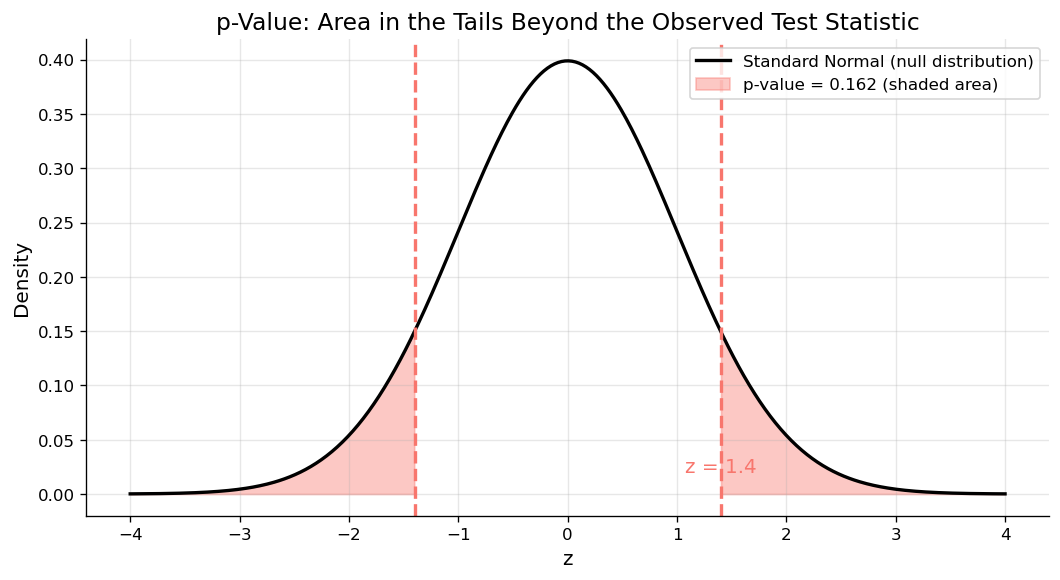

In [3]:
# Visualise the p-value as tail areas
fig, ax = plt.subplots(figsize=(9, 5))
z = np.linspace(-4, 4, 500)
pdf = stats.norm.pdf(z)

ax.plot(z, pdf, "k-", linewidth=2, label="Standard Normal (null distribution)")

# Shade the two tails
mask_right = z >= abs(z_obs)
mask_left = z <= -abs(z_obs)
ax.fill_between(z[mask_right], pdf[mask_right], color="#F8766D", alpha=0.4)
ax.fill_between(
    z[mask_left],
    pdf[mask_left],
    color="#F8766D",
    alpha=0.4,
    label=f"p-value = {p_value:.3f} (shaded area)",
)

# Mark the observed z
ax.axvline(z_obs, color="#F8766D", linewidth=2, linestyle="--")
ax.axvline(-z_obs, color="#F8766D", linewidth=2, linestyle="--")
ax.annotate(
    f"z = {z_obs:.1f}", xy=(z_obs, 0.02), fontsize=12, color="#F8766D", ha="center"
)

ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.set_title("p-Value: Area in the Tails Beyond the Observed Test Statistic")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The red shaded areas are the p-value. If these areas are small (the test statistic falls far into the tails), the data is unlikely under $H_0$ and we reject. If they're large (the test statistic is near zero), the data is consistent with $H_0$.

---

## 5. The Decision Rule: Significance Level $\alpha$

The p-value is a continuous measure of evidence. To make a binary decision (reject or not), we compare it to a pre-specified threshold:

> **Definition.** The **significance level** $\alpha$ is the threshold below which we reject $H_0$.
>
> - If $p\text{-value} \leq \alpha$: **reject** $H_0$ (the result is "statistically significant").
> - If $p\text{-value} > \alpha$: **fail to reject** $H_0$.

Common choices: $\alpha = 0.05$ (5%), $\alpha = 0.01$ (1%), $\alpha = 0.10$ (10%).

$\alpha = 0.05$ means: we accept a 5% risk of rejecting $H_0$ when it's actually true (a **Type I error** — more on this in notebook 03).

**Critical point:** $\alpha$ must be chosen **before** looking at the data. Choosing $\alpha$ after seeing the p-value is cheating — it guarantees you can always reject or not reject as you please.

### Equivalently: rejection regions

Instead of computing a p-value and comparing to $\alpha$, we can equivalently define a **rejection region** — the set of test statistic values that lead to rejection. For a two-sided z-test at $\alpha = 0.05$:

$$\text{Reject } H_0 \text{ if } |Z| > z_{\alpha/2} = z_{0.025} = 1.96$$

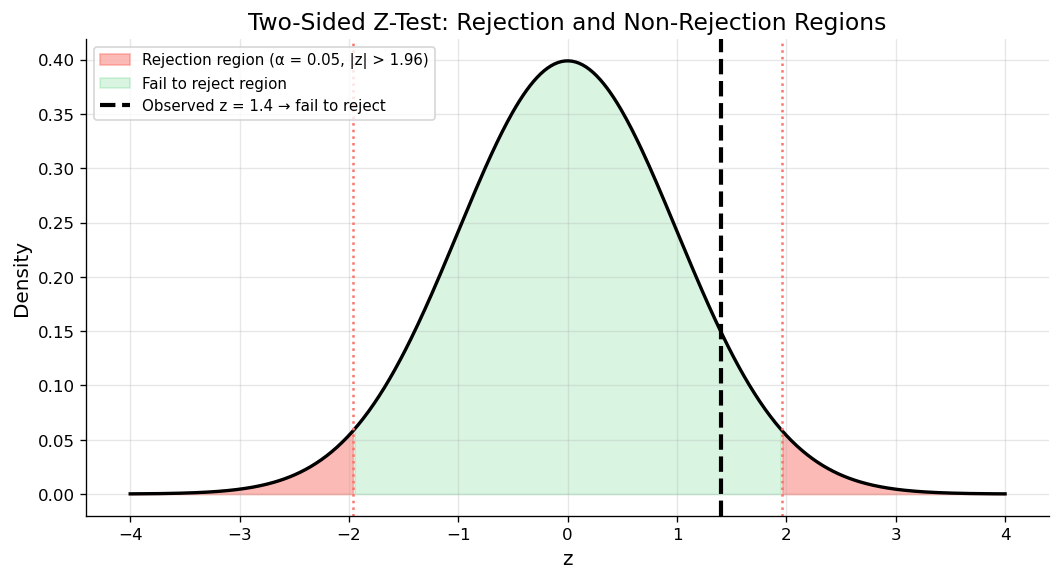

In [4]:
# Rejection regions for different significance levels
fig, ax = plt.subplots(figsize=(9, 5))
z = np.linspace(-4, 4, 500)
pdf = stats.norm.pdf(z)

ax.plot(z, pdf, "k-", linewidth=2)

# Shade rejection regions for α = 0.05
z_crit = stats.norm.ppf(0.975)
mask_r = z >= z_crit
mask_l = z <= -z_crit
ax.fill_between(
    z[mask_r],
    pdf[mask_r],
    color="#F8766D",
    alpha=0.5,
    label=f"Rejection region (α = 0.05, |z| > {z_crit:.2f})",
)
ax.fill_between(z[mask_l], pdf[mask_l], color="#F8766D", alpha=0.5)

# Non-rejection region
mask_center = (z >= -z_crit) & (z <= z_crit)
ax.fill_between(
    z[mask_center],
    pdf[mask_center],
    color="#00BA38",
    alpha=0.15,
    label="Fail to reject region",
)

ax.axvline(z_crit, color="#F8766D", linewidth=1.5, linestyle=":")
ax.axvline(-z_crit, color="#F8766D", linewidth=1.5, linestyle=":")

# Mark our test statistic
ax.axvline(
    z_obs,
    color="black",
    linewidth=2.5,
    linestyle="--",
    label=f"Observed z = {z_obs:.1f} → fail to reject",
)

ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.set_title("Two-Sided Z-Test: Rejection and Non-Rejection Regions")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

Our observed $z = 1.4$ falls in the green (non-rejection) region. We would need $|z| > 1.96$ to reject at $\alpha = 0.05$. That corresponds to $X \geq 60$ or $X \leq 40$ heads — significantly more extreme than what we observed.

---

## 6. The Complete Testing Procedure

Putting it all together, the hypothesis testing procedure has five steps:

| Step                      | Action                                      | Example (coin)                    |
|---------------------------|---------------------------------------------|-----------------------------------|
| 1. State hypotheses       | Formulate $H_0$ and $H_1$                   | $H_0: p = 0.5$, $H_1: p \neq 0.5$ |
| 2. Choose $\alpha$        | Set significance level *before* seeing data | $\alpha = 0.05$                   |
| 3. Compute test statistic | Summarise data into $T$                     | $Z = (57 - 50)/5 = 1.4$           |
| 4. Compute p-value        | How extreme is $T$ under $H_0$?             | $p = 0.162$                       |
| 5. Decide                 | Compare p-value to $\alpha$                 | $0.162 > 0.05$ → fail to reject   |

### A second example: more data

Now suppose we flip the same coin 1000 times and get 570 heads (same proportion, 57%). Let's redo the test:

In [5]:
# Same proportion, more data
n2, x2 = 1000, 570
z2 = (x2 - n2 * 0.5) / np.sqrt(n2 * 0.5 * 0.5)
p2 = 2 * stats.norm.sf(abs(z2))

print(f"n = {n2}, X = {x2} ({x2 / n2:.1%})")
print(f"Z = {z2:.2f}")
print(f"p-value = {p2:.6f}")
print(
    f"\nAt α = 0.05: {'REJECT H₀ — evidence of bias' if p2 < 0.05 else 'Fail to reject'}"
)

n = 1000, X = 570 (57.0%)
Z = 4.43
p-value = 0.000010

At α = 0.05: REJECT H₀ — evidence of bias


With $n = 100$, 57% heads was not significant. With $n = 1000$, the same 57% is highly significant ($p \approx 0.00002$). **The same effect becomes detectable with more data.** This is a fundamental insight: statistical significance depends on both the *effect size* and the *sample size*. We'll formalise this as **statistical power** in notebook 03.

---

## 7. Verifying the Framework: p-Values Under $H_0$

A crucial property: if $H_0$ is true, p-values are **uniformly distributed** on $[0, 1]$. This means:
- 5% of the time, the p-value will be below 0.05 (leading to a false rejection at $\alpha = 0.05$).
- 1% of the time, it will be below 0.01.
- The rejection rate under $H_0$ equals $\alpha$ — by construction.

This is worth verifying empirically:

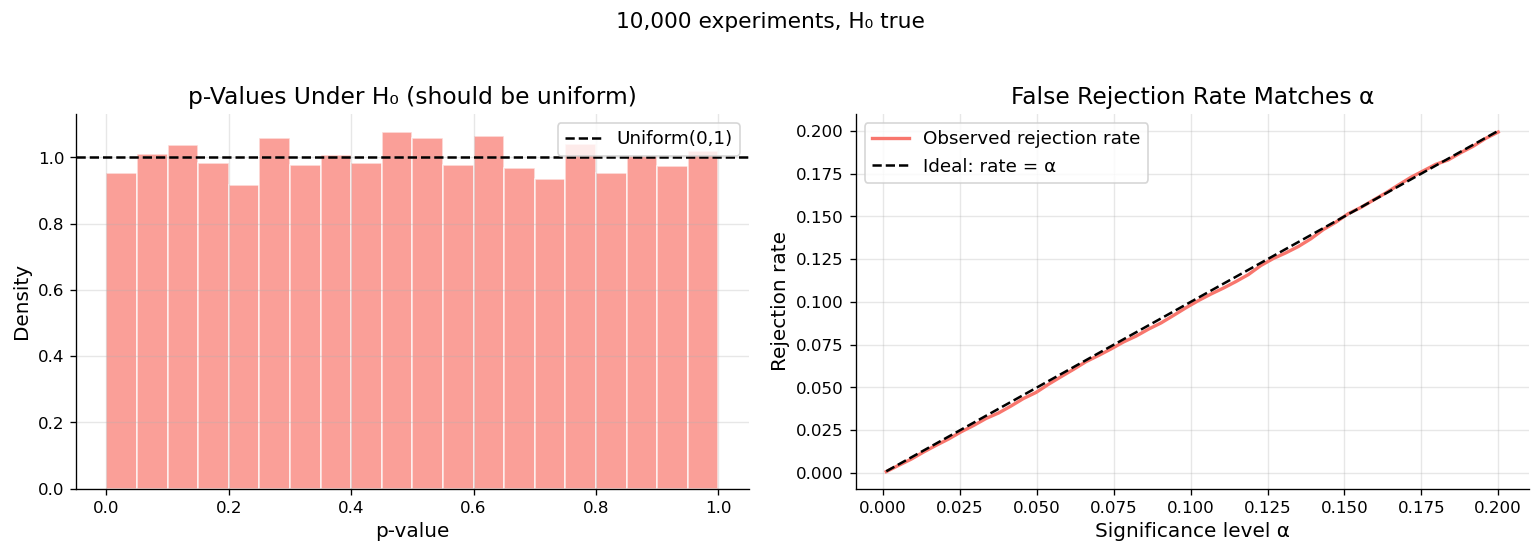

Rejection rate at α = 0.05: 0.048  (should be ≈ 0.05)
Rejection rate at α = 0.01: 0.009  (should be ≈ 0.01)


In [6]:
# Monte Carlo: p-values should be uniform under H₀
n_experiments = 10_000
n_sample = 50
true_mu = 0  # H₀ is TRUE

p_values = []
for _ in range(n_experiments):
    sample = rng.normal(true_mu, 1, n_sample)
    # z-test for μ = 0 (known σ = 1)
    z = sample.mean() / (1 / np.sqrt(n_sample))
    p = 2 * stats.norm.sf(abs(z))
    p_values.append(p)

p_values = np.array(p_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram of p-values
axes[0].hist(p_values, bins=20, density=True, alpha=0.7, edgecolor="white")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="Uniform(0,1)")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Density")
axes[0].set_title("p-Values Under H₀ (should be uniform)")
axes[0].legend()

# Rejection rates at different α
alphas = np.linspace(0.001, 0.20, 50)
rejection_rates = [np.mean(p_values <= a) for a in alphas]
axes[1].plot(alphas, rejection_rates, linewidth=2, label="Observed rejection rate")
axes[1].plot(alphas, alphas, "k--", linewidth=1.5, label="Ideal: rate = α")
axes[1].set_xlabel("Significance level α")
axes[1].set_ylabel("Rejection rate")
axes[1].set_title("False Rejection Rate Matches α")
axes[1].legend()

plt.suptitle(f"{n_experiments:,} experiments, H₀ true", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(
    f"Rejection rate at α = 0.05: {np.mean(p_values <= 0.05):.3f}  (should be ≈ 0.05)"
)
print(
    f"Rejection rate at α = 0.01: {np.mean(p_values <= 0.01):.3f}  (should be ≈ 0.01)"
)

The left plot shows a flat histogram — p-values are uniformly distributed when $H_0$ is true. The right plot confirms that the false rejection rate equals $\alpha$ at every significance level. This is the **calibration property** of a well-constructed test.

---

## 8. Common Misinterpretations

P-values are among the most misunderstood concepts in statistics. Here are the most common errors:

| Misconception                                             | Reality                                                                                                                                               |
|-----------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------|
| "The p-value is the probability that $H_0$ is true"       | **No.** The p-value assumes $H_0$ is true and measures how surprising the data is. $P(H_0 \mid \text{data})$ requires Bayesian inference (Module 07). |
| "$p < 0.05$ means the effect is large"                    | **No.** A tiny effect can be significant with enough data (as we saw: 57% bias was non-significant at $n=100$ but significant at $n=1000$).           |
| "$p > 0.05$ means there is no effect"                     | **No.** It means we don't have enough evidence to detect it. Absence of evidence is not evidence of absence.                                          |
| "$p = 0.049$ and $p = 0.051$ are fundamentally different" | **No.** The 0.05 threshold is a convention, not a law of nature. These p-values represent essentially the same strength of evidence.                  |

The p-value tells you how *compatible* the data is with $H_0$. It does **not** tell you the probability that $H_0$ is true, the probability that the result is "real", or the size of the effect. Report the p-value alongside the **effect size** and a **confidence interval** for a complete picture.

---

## 9. The Neyman–Pearson Framework

The testing procedure we've described follows the **Neyman–Pearson paradigm** (1933). Its key insight: a test is not about any single experiment — it's about **long-run error rates** across many experiments.

When we set $\alpha = 0.05$, we're saying: "In the long run, if $H_0$ is true, I will incorrectly reject it at most 5% of the time." This is a property of the *procedure*, not of any individual result.

This is philosophically different from asking "What do I believe after seeing this data?" (the Bayesian approach in Module 07). Both frameworks are valid; they answer different questions.

### Connection to confidence intervals

There is a deep duality between hypothesis tests and confidence intervals:

> A two-sided test at level $\alpha$ rejects $H_0: \mu = \mu_0$ if and only if $\mu_0$ falls **outside** the $(1-\alpha)$ confidence interval for $\mu$.

This means you can read the test result off the CI: if the hypothesised value is in the interval, fail to reject; if it's outside, reject.

In [7]:
# Demonstrate the CI ↔ test duality
sample = rng.normal(loc=2.3, scale=5, size=40)  # true μ = 2.3

xbar = sample.mean()
se = sample.std(ddof=1) / np.sqrt(len(sample))
ci_lo = xbar - 1.96 * se
ci_hi = xbar + 1.96 * se

# Test H₀: μ = 0
z_test = xbar / se
p_test = 2 * stats.norm.sf(abs(z_test))

print(f"Sample mean: {xbar:.3f}")
print(f"95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"\nTest H₀: μ = 0")
print(f"  z = {z_test:.3f}, p = {p_test:.4f}")
print(
    f"  μ₀ = 0 is {'outside' if p_test < 0.05 else 'inside'} the 95% CI → "
    f"{'reject' if p_test < 0.05 else 'fail to reject'}"
)

# Test H₀: μ = 1
z_test2 = (xbar - 1) / se
p_test2 = 2 * stats.norm.sf(abs(z_test2))
print(f"\nTest H₀: μ = 1")
print(f"  z = {z_test2:.3f}, p = {p_test2:.4f}")
print(
    f"  μ₀ = 1 is {'outside' if p_test2 < 0.05 else 'inside'} the 95% CI → "
    f"{'reject' if p_test2 < 0.05 else 'fail to reject'}"
)

Sample mean: 1.442
95% CI: [-0.183, 3.067]

Test H₀: μ = 0
  z = 1.739, p = 0.0820
  μ₀ = 0 is inside the 95% CI → fail to reject

Test H₀: μ = 1
  z = 0.533, p = 0.5939
  μ₀ = 1 is inside the 95% CI → fail to reject


---

## Exercises

**Exercise 1.1 (Formulating hypotheses).** A bakery claims their loaves weigh 500g on average. You weigh 25 loaves and find $\bar{x} = 492$ with $s = 20$. State $H_0$ and $H_1$, compute the test statistic and p-value, and make a decision at $\alpha = 0.05$.

**Exercise 1.2 (One-sided test).** In the coin example, suppose your alternative hypothesis is $H_1: p > 0.5$ (one-sided). Compute the one-sided p-value for $X = 57$ out of $n = 100$. How does it compare to the two-sided p-value? Why?

**Exercise 1.3 (p-value uniformity).** Repeat the Monte Carlo experiment from Section 7 but using a **t-test** instead of a z-test (replace known $\sigma = 1$ with the sample standard deviation $s$). Are the p-values still uniform under $H_0$?

**Exercise 1.4 (Effect size vs. sample size).** A drug reduces blood pressure by an average of 2 mmHg ($\sigma = 10$). For sample sizes $n = 10, 50, 100, 500, 1000$, compute the z-test statistic and p-value for $H_0: \mu = 0$ vs. $H_1: \mu \neq 0$. At what $n$ does the effect become significant at $\alpha = 0.05$? Is a 2 mmHg reduction clinically meaningful regardless of significance?

**Exercise 1.5 (CI-test duality).** Generate 100 samples of size $n = 20$ from $\mathcal{N}(0, 1)$. For each, compute the 95% CI and test $H_0: \mu = 0$. Verify that the test rejects if and only if 0 is outside the CI.

**Exercise 1.6 (Challenge — p-hacking).** Generate 20 independent variables, all from $\mathcal{N}(0, 1)$ (no real effects). Test each for $\mu \neq 0$ at $\alpha = 0.05$. How many false rejections do you expect? Simulate 1,000 times and verify. This is the **multiple testing** problem (notebook 04).

---

## Key Takeaways

1. Hypothesis testing asks: **is the observed effect real, or could it be noise?**
2. $H_0$ (no effect) is the default; we need evidence to reject it in favour of $H_1$.
3. The **test statistic** summarises evidence; the **p-value** measures how surprising the data is under $H_0$.
4. Reject $H_0$ if $p \leq \alpha$. The significance level $\alpha$ controls the false rejection rate.
5. P-values are **uniform under $H_0$** — this is what makes the procedure calibrated.
6. Significance depends on **both effect size and sample size** — a tiny effect can be significant with enough data.
7. P-values are **not** the probability that $H_0$ is true. Always report effect sizes and confidence intervals alongside.

**Next:** [02_common_tests.ipynb](02_common_tests.ipynb) — The specific tests: z-test, t-test, chi-square test, F-test — when to use which, derivations, and from-scratch implementations.

In [8]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
